In [4]:
import pandas as pd
from IPython.display import display
import argparse
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import re


# Pandas display config
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('max_colwidth', None)

# DIRS
OUTDIR                  = "outfiles-data-exploration"
DB_DIR                  = "database-files"
HLA_DIR                 = "hla-pred-files"

# INPUTS
CEDAR_IMMUNOGENIC_FILE       = f"{DB_DIR}/imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx"
CEDAR_NON_IMMUNOGENIC_FILE   = f"{DB_DIR}/non-imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx"
CEDAR_MHC_NON_BINDERS_FILE   = f"{DB_DIR}/cedar-mhc-non-binders-neo-self-viral-8-11mers.xlsx"

# OUTPUTS
ALLELES_OUTFILE         = f"{OUTDIR}/alleles_cedar_traintest.txt"
PEPTIDES_OUTFILE        = f"{OUTDIR}/peptides_cedar_traintest.txt"
PEPTIDES_OUTFILE_2      = f"{OUTDIR}/peptides_cedar_traintest_nonimm.txt"
PEPTIDES_TABLE_OUTFILE  = f"{OUTDIR}/cedar_traintest_alleles.csv"

LIKELY_IMMUNOGENIC_FILE     = f"{OUTDIR}/cedar_likely_imm.txt"
MAYBE_IMMUNOGENIC_FILE      = f"{OUTDIR}/cedar_maybe_imm.txt"
LIKELY_NON_IMMUNOGENIC_FILE = f"{OUTDIR}/cedar_likely_non_imm.txt"
MAYBE_NON_IMMUNOGENIC_FILE  = f"{OUTDIR}/cedar_maybe_non_imm.txt"

# ── Manual ALLELES_TO_ADD: alleles known to be missing from the reference list ──
ALLELES_TO_ADD = {'HLA-A*80:01'}
ALLELES_TO_REMOVE = {'HLA-A*02:402', 'HLA-B*44:01', 'H2-Ld'}

AAs = set("ARNDCQEGHILKMFPSTWYV")

In [5]:
def excelToDf(filepath: str) -> pd.DataFrame:
    '''
    Read an Excel file and return it as a pandas DataFrame.
    '''
    try:
        df = pd.read_excel(filepath)
        df.columns = df.columns.str.strip()
        print(f'Successfully loaded file: {filepath}')
        print(f'Total rows: {len(df)}')
        #print(f'Columns found: {list(df.columns)}\n')
        return df

    except FileNotFoundError:
        print(f'Error: File not found at path: {filepath}')
        sys.exit(1)
    except Exception as e:
        print(f'Error loading file: {e}')
        sys.exit(1)


In [20]:
## CEDAR all 8-11mer immunogenic peptides with MHC data
# df_imm_test = excelToDf(CEDAR_IMMUNOGENIC_FILE)
# df_non_test = excelToDf(CEDAR_NON_IMMUNOGENIC_FILE)

# print(df_imm_test.shape)
# print(df_non_test.shape)

In [ ]:
# Drop rows where the epitope name contains a space (non-peptide entries)
# df_imm_test = df_imm_test[~df_imm_test['Epitope - Name'].str.contains(' ', na=False)]

# print(df_imm_test.shape)

# resp = df_imm_test[['in vitro Responder Cell - Name', 'Assay - Method', 'Assay - Response measured']].drop_duplicates(subset=['Assay - Method', 'Assay - Response measured'])
# display(resp)
# # display(resp[resp['Assay - Response measured'].str.contains('release')])
# # display(resp[~resp['Assay - Response measured'].str.contains('release')])
# display(resp['in vitro Responder Cell - Name'].unique())

# pd.set_option('display.max_rows', None)
# display(
#     resp[['Assay - Method', 'Assay - Response measured']]
#     .drop_duplicates()
#     .sort_values(by='Assay - Method')
# )
# pd.reset_option('display.max_rows')

# df_ifng = df_imm_test[df_imm_test['Assay - Response measured'].str.contains('IFNg')]
# print(df_ifng.shape)

# df_ifng = df_ifng.drop_duplicates(subset=['Epitope - Name'])
# print(df_ifng.shape)

# # NON_IMMUNOGENIC

# df_non_test = df_non_test[~df_non_test['Epitope - Name'].str.contains(' ', na=False)]

# print(df_non_test.shape)

# df_non_ifng = df_non_test[df_non_test['Assay - Response measured'].str.contains('IFNg')]
# print(df_non_ifng.shape)

# df_non_ifng = df_non_ifng.drop_duplicates(subset=['Epitope - Name'])
# print(df_non_ifng.shape)

# Deduplicate on (peptide, MHC allele) pairs
# cedar_df = df.drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
# print(f"\nShape after (peptide, MHC) deduplication: {cedar_df.shape}")
# display(cedar_df.head())

# # Report peptides that map to more than one MHC allele
# mhc_per_peptide = df.groupby('Epitope - Name')['MHC Restriction - Name'].nunique()
# multi_mhc = mhc_per_peptide[mhc_per_peptide > 1]
# print(f"\nPeptides mapping to more than one MHC allele: {len(multi_mhc)}")
# display(multi_mhc.head(5))

# # Deduplicate to one row per unique peptide sequence
# cedar_unique_df = cedar_df.drop_duplicates(subset='Epitope - Name')
# print(f"\nShape after per-peptide deduplication: {cedar_unique_df.shape}")
# display(cedar_unique_df.head())

NameError: name 'df_imm_test' is not defined

Original Visualisation code starts below

In [6]:
def load_and_process_cedar(excel_path: str, label: str, columns=None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load and process a CEDAR Excel file, returning both the deduplicated
    and unique-peptide DataFrames.

    Parameters
    ----------
    excel_path : str
        Path to the input .xlsx file.
    label : str
        Human-readable label (e.g. 'Immunogenic', 'Non-Immunogenic')
        used purely for printed output.

    Returns
    -------
    cedar_df : pd.DataFrame
        Deduplicated on (Epitope - Name, MHC Restriction - Name).
    cedar_unique_df : pd.DataFrame
        Further deduplicated to one row per peptide.
    """
    if columns is None:
        columns = [
            'Epitope - Name',
            'Epitope - Molecule Parent',
            'in vitro Responder Cell - Name',
            'Assay - Method',
            'Assay - Response measured',
            'MHC Restriction - Name',
            'Epitope - Mutation',
            'Epitope - Molecule Parent IRI',
            'Epitope - Starting Position',
            'Epitope - Object Type',
            'Epitope - Modifications',
            'Epitope - Synonyms',
            'Related Object - Epitope Relation',
            'Related Object - IRI',
            'Epitope - Source Organism'
        ]

    print(f"\n{'='*60}")
    print(f"  Processing: {label}")
    print(f"  File: {excel_path}")
    print(f"{'='*60}")

    df = excelToDf(excel_path)[columns]

    # Drop rows where the epitope name contains a space (non-peptide entries)
    df = df[~df['Epitope - Name'].str.contains(' ', na=False)]

    df = df[df['Epitope - Name'].apply(lambda pep: all(aa in AAs for aa in pep))]

    cedar_df = df
    # Report peptides that map to more than one MHC allele
    mhc_per_peptide = df.groupby('Epitope - Name')['MHC Restriction - Name'].nunique()
    multi_mhc = mhc_per_peptide[mhc_per_peptide > 1]
    print(f"\nPeptides mapping to more than one MHC allele: {len(multi_mhc)}")
    display(multi_mhc.head(1))

    # Deduplicate to one row per unique peptide sequence
    cedar_unique_df = cedar_df.drop_duplicates(subset='Epitope - Name')
    print(f"\nShape after per-peptide deduplication: {cedar_unique_df.shape}")
    display(cedar_unique_df.head())

    return cedar_df, cedar_unique_df

In [7]:
FILES = {
    #"Immunogenic":     f"{DB_DIR}/tcell_table_export_1781874891.xlsx",
    "Immunogenic":     CEDAR_IMMUNOGENIC_FILE,
    "Non-Immunogenic": CEDAR_NON_IMMUNOGENIC_FILE,
    #"Non-MHC" : CEDAR_MHC_NON_BINDERS_FILE
    #"Non-MHC-Binding" : CEDAR_MHC_NON_BINDERS_FILE
}

results = {}   # keyed by label → {"df": ..., "unique_df": ...}

for label, path in FILES.items():
    if label == 'Non-MHC-Binding':
        non_binders_columns = [
            'Epitope - Name',
            'Epitope - Molecule Parent',
            'MHC Restriction - Name',
            'Epitope - Mutation',
            'Epitope - Molecule Parent IRI',
            'Epitope - Starting Position',
            'Related Object - Epitope Relation',
            'Related Object - IRI',
            'Epitope - Source Organism'
        ]
        df, unique_df = load_and_process_cedar(path, label, non_binders_columns)
    else:
        df, unique_df = load_and_process_cedar(path, label)

    if label == 'Non-Immunogenic':
        immunogenic_peptides = results['Immunogenic']['unique_df']['Epitope - Name']
        df = df[~df['Epitope - Name'].isin(immunogenic_peptides)]
        unique_df = unique_df[~unique_df['Epitope - Name'].isin(immunogenic_peptides)]

    neoag_df, self_df, viral_df, missing_info_df = None, None, None, None
        
    df_tmp = unique_df[unique_df['Epitope - Source Organism'].str.contains("Homo")]
    self_df = df_tmp[df_tmp['Epitope - Mutation'].isna()]

    neoag_df = unique_df[unique_df['Epitope - Source Organism'].isna()]
    neoag_peps = neoag_df['Epitope - Name']
    missing_info_peps = neoag_df[neoag_df['Related Object - Epitope Relation'].isna()]['Epitope - Name']

    # For some reason, there are rows that have mutation columns when the source organism has Homo
    # , while most others just have NA for source org
    neoag_df = pd.concat([neoag_df, df_tmp[df_tmp['Epitope - Mutation'].notna()]])
    neoag_df = neoag_df[neoag_df['Related Object - Epitope Relation'].notna()]
    
    viral_df = unique_df[~unique_df['Epitope - Source Organism'].str.contains("Homo")]
    viral_df = viral_df[viral_df['Epitope - Source Organism'].notna()]
        

    results[label] = {"df": df, "unique_df": unique_df, "neoag_df": neoag_df, "self_df": self_df, "viral_df": viral_df, "missing_df": missing_info_df}


  Processing: Immunogenic
  File: database-files/imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx
Successfully loaded file: database-files/imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx
Total rows: 33212

Peptides mapping to more than one MHC allele: 1006


Epitope - Name
AAFKRSCLK    2
Name: MHC Restriction - Name, dtype: int64


Shape after per-peptide deduplication: (9663, 15)


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
0,KLEDLERDL,Large delta antigen,NaN,multimer/tetramer,qualitative binding,HLA-A*02:01,NaN,http://www.uniprot.org/uniprot/P29996,26.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis delta virus TW2667
2,ITKKVADLVGF,Melanoma-associated antigen 1,T cell CD8+,51 chromium,cytotoxicity,HLA-B*57:02,NaN,http://www.uniprot.org/uniprot/P43355,102.0,Linear peptide,NaN,NaN,NaN,NaN,Homo sapiens
5,AEWPTFNVGW,NaN,T cell CD8+,ELISPOT,IFNg release,HLA-B*44:03,NaN,NaN,41.0,Linear peptide,NaN,NaN,NaN,NaN,Friend murine leukemia virus
6,APIWPYEILY,NaN,T cell CD8+,ELISPOT,IFNg release,HLA-B*35:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,analog,NaN,NaN
7,LIYDSSLCDL,Mammaglobin-A,NaN,ELISPOT,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/Q13296,83.0,Linear peptide,NaN,NaN,NaN,NaN,Homo sapiens



  Processing: Non-Immunogenic
  File: database-files/non-imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx
Successfully loaded file: database-files/non-imm_CEDAR_MHC_neoag_self_viral_8-11.xlsx
Total rows: 19945

Peptides mapping to more than one MHC allele: 942


Epitope - Name
AAAAQQIQV    2
Name: MHC Restriction - Name, dtype: int64


Shape after per-peptide deduplication: (12633, 15)


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
0,ALAHGVRAL,Genome polyprotein,PBMC,ELISA,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/P27958,150.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis C virus subtype 1b
1,NLPGCSFSI,Genome polyprotein,PBMC,ELISA,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/P27958,168.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis C virus subtype 1b
2,ILHTPGCV,Genome polyprotein,PBMC,ELISA,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/P27958,220.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis C virus subtype 1b
3,SMVGNWAKV,Genome polyprotein,PBMC,ELISA,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/P27958,363.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis C virus subtype 1b
4,SLLAPGAKQNV,Genome polyprotein,PBMC,ELISA,IFNg release,HLA-A2,NaN,http://www.uniprot.org/uniprot/P27958,401.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis C virus subtype 1b


In [8]:
# Downstream access
# results["Immunogenic"]["df"]          → cedar_df for immunogenic
# results["Non-Immunogenic"]["unique_df"] → cedar_unique_df for non-immunogenic

# ── Remove overlapping peptides from non-immunogenic set ────────────────────

imm_df, non_imm_df = results['Immunogenic']['df'], results['Non-Immunogenic']['df']

print(f'Imm df with duplicates: {imm_df.shape}')
print(f'Non-Imm df with duplicates: {non_imm_df.shape}')
print()

def get_assay_peptides(df, assays: list):
    peps = set()
    for a in assays:
        print(f'{a}')
        assay_df = df[["Epitope - Name", "Assay - Method"]].drop_duplicates(subset=["Epitope - Name", "Assay - Method"])
        assay_df = assay_df[assay_df['Assay - Method'] == a]
        peps.update(assay_df['Epitope - Name'])
        print(assay_df.shape[0])
        print('-'*60)
    return peps


good_assays = ['multimer/tetramer', 'ELISPOT', '51 chromium', '3H-thymidine', 'intracellular staining', 'in vivo skin test']

imm_peps = set(imm_df['Epitope - Name'])
likely_immunogenic_peps = get_assay_peptides(imm_df, good_assays)
print('='*60)
print(f"Likely Immunogenic peptides: {len(likely_immunogenic_peps)}")

print('='*60)
non_imm_peps = set(non_imm_df['Epitope - Name'])
likely_non_immunogenic_peps = get_assay_peptides(non_imm_df, good_assays)
print('='*60)
print(f"Likely Non-Immunogenic peptides: {len(likely_non_immunogenic_peps)}")

Imm df with duplicates: (32970, 15)
Non-Imm df with duplicates: (13503, 15)

multimer/tetramer
4900
------------------------------------------------------------
ELISPOT
3147
------------------------------------------------------------
51 chromium
981
------------------------------------------------------------
3H-thymidine
82
------------------------------------------------------------
intracellular staining
75
------------------------------------------------------------
in vivo skin test
40
------------------------------------------------------------
Likely Immunogenic peptides: 7721
multimer/tetramer
4684
------------------------------------------------------------
ELISPOT
2789
------------------------------------------------------------
51 chromium
274
------------------------------------------------------------
3H-thymidine
48
------------------------------------------------------------
intracellular staining
4
------------------------------------------------------------
in vivo sk

In [ ]:
# def writeFile(filepath: str, peps: set):
#     with open(filepath, 'w') as f:
#         for p in peps:
#             f.write(f'{p}\n')

# writeFile(LIKELY_IMMUNOGENIC_FILE, likely_immunogenic_peps)
# writeFile(MAYBE_IMMUNOGENIC_FILE, (imm_peps - likely_immunogenic_peps))

# writeFile(LIKELY_NON_IMMUNOGENIC_FILE, likely_non_immunogenic_peps)
# writeFile(MAYBE_NON_IMMUNOGENIC_FILE, (non_imm_peps - likely_non_immunogenic_peps))

### Num peptides with Uniprot accessions

In [10]:
# imm_with_uniprot = results["Immunogenic"]["unique_df"]
# print(f"Num Imm peps: {imm_with_uniprot.shape[0]}")
# imm_with_uniprot = imm_with_uniprot[imm_with_uniprot['Epitope - Molecule Parent IRI'].str.contains('uniprot')]
# print(f"Num uniprot Imm peps: {imm_with_uniprot.shape[0]}")

# non_imm_with_uniprot = results["Non-Immunogenic"]["unique_df"]
# print(f"Num Non-Imm peps: {non_imm_with_uniprot.shape[0]}")
# non_imm_with_uniprot = non_imm_with_uniprot[non_imm_with_uniprot['Epitope - Molecule Parent IRI'].str.contains('uniprot')]
# print(f"Num uniprot Non-Imm peps: {non_imm_with_uniprot.shape[0]}")



### Epitope composition of the datasets

In [9]:
imm_df = results["Immunogenic"]["unique_df"]
non_imm_df = results["Non-Immunogenic"]["unique_df"]

def print_column_counts(df):
    print(f"Linear epitopes - {df[df['Epitope - Object Type'].str.contains('Linear')].shape[0]}")
    print(f"Uniprot IDs - {df[df['Epitope - Molecule Parent IRI'].str.contains('uniprot')].shape[0]}")
    print(f"Epitope Index pos - {df[~df['Epitope - Starting Position'].isna()].shape[0]}")
    print(f"Modified epitopes - {df[~df['Epitope - Modifications'].isna()].shape[0]}")
    print(f"Synonym epitopes - {df[~df['Epitope - Synonyms'].isna()].shape[0]}")
    print(f"Epitope Relation Records - {df[~df['Related Object - Epitope Relation'].isna()].shape[0]}")
    print(f"Unique Epitope Relations - {df[~df['Related Object - Epitope Relation'].isna()]['Related Object - Epitope Relation'].nunique()}")
    print(f"Assay Methods - {df[~df['Assay - Method'].isna()]['Assay - Method'].nunique()}")


print_column_counts(imm_df)
print('-'*60)
print_column_counts(non_imm_df)

#display(df[~df['Related Object - Epitope Relation'].isna()].head())

Linear epitopes - 9663
Uniprot IDs - 6487
Epitope Index pos - 6154
Modified epitopes - 0
Synonym epitopes - 0
Epitope Relation Records - 2856
Unique Epitope Relations - 6
Assay Methods - 19
------------------------------------------------------------
Linear epitopes - 9836
Uniprot IDs - 4276
Epitope Index pos - 4231
Modified epitopes - 0
Synonym epitopes - 0
Epitope Relation Records - 5421
Unique Epitope Relations - 6
Assay Methods - 12


In [13]:
# keys = ['neoag_df', 'self_df', 'viral_df', 'missing_df']
# labels = ['Immunogenic', 'Non-Immunogenic', 'Non-MHC-Binding']


# for label in labels:
#     print('='*60)
#     print(f'{label}\t\tuniprot')
#     df = results[label]
#     total, uni_total = 0, 0
#     for key in keys:
#         num = df[key].shape[0]
#         total += num

#         num_with_ids = df[key][df[key]['Epitope - Molecule Parent IRI'].notna()].shape[0]
#         uni_total += num_with_ids

#         print(f'{key}:\t{num}\t({num_with_ids})')

#         df[key]['Epitope - Name'].to_csv(f'{OUTDIR}/traintest_subgroups/cedar_{label}_{key}.txt', index=False, header=False)

#     print('-'*20)
#     print(f'Total:\t\t{total}\t({uni_total})')

# #display(results['Immunogenic']['neoag_df'][results['Immunogenic']['neoag_df']['Related Object - IRI'].notna()])

# print('='*60)
# print('Testing Immunogenic records with no source organism')
# imm_un_df = results[labels[0]]['unique_df']
# missing_info_records = imm_un_df[imm_un_df['Epitope - Source Organism'].isna() & imm_un_df['Related Object - Epitope Relation'].isna()]
# print(f'NA source Org and NA Related Object (Mutation): {missing_info_records.shape[0]}')
# display(missing_info_records.head())
# print('-'*60)
# print(f'NA source Org, but Related Object: {imm_un_df[imm_un_df['Epitope - Source Organism'].isna()].shape[0] - missing_info_records.shape[0]}')

In [14]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np
# import pandas as pd


# BLUE   = "#3A7DC9"
# ORANGE = "#E07B39"
# ALPHA  = 0.88


# def get_binary_counts(df):
#     """Fixed yes/no feature counts (excludes the two expanded fields)."""
#     return {
#         "Linear epitopes":    df["Epitope - Object Type"].str.contains("Linear", na=False).sum(),
#         "UniProt IDs":        df["Epitope - Molecule Parent IRI"].str.contains("uniprot", na=False).sum(),
#         "Has position index": df["Epitope - Starting Position"].notna().sum(),
#         "Has modifications":  df["Epitope - Modifications"].notna().sum(),
#         "Has synonyms":       df["Epitope - Synonyms"].notna().sum(),
#     }


# def get_class_counts(df, col):
#     """Per-class counts for a categorical column, NaNs excluded."""
#     return df[col].value_counts(dropna=True)


# def _draw_grouped_bars(ax_count, ax_pct, labels, imm_vals, non_vals,
#                        imm_total, non_total, bar_width=0.38,
#                        count_labels=True, pct_labels=True,
#                        xlabel_rotation=30, xlabel_fontsize=9):
#     x = np.arange(len(labels))

#     # --- counts ---
#     b1 = ax_count.bar(x - bar_width / 2, imm_vals,  bar_width,
#                       label="Immunogenic",     color=BLUE,   alpha=ALPHA)
#     b2 = ax_count.bar(x + bar_width / 2, non_vals,  bar_width,
#                       label="Non-Immunogenic", color=ORANGE, alpha=ALPHA)
#     ax_count.set_ylabel("Count")
#     ax_count.set_xticks(x)
#     ax_count.set_xticklabels(labels, rotation=xlabel_rotation,
#                               ha="right", fontsize=xlabel_fontsize)
#     ax_count.legend(fontsize=9)
#     ax_count.spines[["top", "right"]].set_visible(False)
#     ax_count.yaxis.grid(True, alpha=0.35, linestyle="--")
#     ax_count.set_axisbelow(True)
#     if count_labels:
#         for bar in list(b1) + list(b2):
#             h = bar.get_height()
#             ax_count.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
#                           f"{int(h):,}", ha="center", va="bottom", fontsize=7)

#     # --- percentages ---
#     imm_pct = [v / imm_total * 100 for v in imm_vals]
#     non_pct = [v / non_total * 100 for v in non_vals]
#     b3 = ax_pct.bar(x - bar_width / 2, imm_pct,  bar_width,
#                     label="Immunogenic",     color=BLUE,   alpha=ALPHA)
#     b4 = ax_pct.bar(x + bar_width / 2, non_pct,  bar_width,
#                     label="Non-Immunogenic", color=ORANGE, alpha=ALPHA)
#     ax_pct.set_ylabel("% of group total")
#     ax_pct.set_ylim(0, max(max(imm_pct), max(non_pct)) * 1.18 + 2)
#     ax_pct.set_xticks(x)
#     ax_pct.set_xticklabels(labels, rotation=xlabel_rotation,
#                             ha="right", fontsize=xlabel_fontsize)
#     ax_pct.legend(fontsize=9)
#     ax_pct.spines[["top", "right"]].set_visible(False)
#     ax_pct.yaxis.grid(True, alpha=0.35, linestyle="--")
#     ax_pct.set_axisbelow(True)
#     if pct_labels:
#         for bar in list(b3) + list(b4):
#             h = bar.get_height()
#             ax_pct.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
#                         f"{h:.1f}%", ha="center", va="bottom", fontsize=7)


# def _draw_grouped_bars_h(ax_count, ax_pct, labels, imm_vals, non_vals,
#                          imm_total, non_total, bar_width=0.38):
#     """Horizontal grouped bars for long label lists (assay methods, response measured, etc.)."""
#     y = np.arange(len(labels))

#     # --- counts ---
#     b1 = ax_count.barh(y + bar_width / 2, imm_vals,  bar_width,
#                        label="Immunogenic",     color=BLUE,   alpha=ALPHA)
#     b2 = ax_count.barh(y - bar_width / 2, non_vals,  bar_width,
#                        label="Non-Immunogenic", color=ORANGE, alpha=ALPHA)
#     ax_count.set_xlabel("Count")
#     ax_count.set_yticks(y)
#     ax_count.set_yticklabels(labels, fontsize=8)
#     ax_count.legend(fontsize=9)
#     ax_count.spines[["top", "right"]].set_visible(False)
#     ax_count.xaxis.grid(True, alpha=0.35, linestyle="--")
#     ax_count.set_axisbelow(True)
#     for bar in list(b1) + list(b2):
#         w = bar.get_width()
#         ax_count.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
#                       f"{int(w):,}", va="center", fontsize=7)

#     # --- percentages ---
#     imm_pct = [v / imm_total * 100 for v in imm_vals]
#     non_pct = [v / non_total * 100 for v in non_vals]
#     b3 = ax_pct.barh(y + bar_width / 2, imm_pct,  bar_width,
#                      label="Immunogenic",     color=BLUE,   alpha=ALPHA)
#     b4 = ax_pct.barh(y - bar_width / 2, non_pct,  bar_width,
#                      label="Non-Immunogenic", color=ORANGE, alpha=ALPHA)
#     ax_pct.set_xlabel("% of group total")
#     ax_pct.set_yticks(y)
#     ax_pct.set_yticklabels(labels, fontsize=8)
#     ax_pct.legend(fontsize=9)
#     ax_pct.spines[["top", "right"]].set_visible(False)
#     ax_pct.xaxis.grid(True, alpha=0.35, linestyle="--")
#     ax_pct.set_axisbelow(True)
#     for bar in list(b3) + list(b4):
#         w = bar.get_width()
#         ax_pct.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
#                     f"{w:.1f}%", va="center", fontsize=7)


# def _get_organism_slices(df, col, top_n=5):
#     """Return (labels, values) with top_n organisms + 'Other' remainder."""
#     counts = df[col].value_counts(dropna=True)
#     top    = counts.iloc[:top_n]
#     other  = counts.iloc[top_n:].sum()
#     labels = list(top.index) + (["Other"] if other > 0 else [])
#     values = list(top.values) + ([other]  if other > 0 else [])
#     return labels, values


# def _draw_pie(ax, labels, values, title, top_n=5):
#     """Draw a pie chart, colouring 'Other' grey and adding a count legend."""
#     # colour palette: distinct hues for top slices, grey for Other
#     palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
#                "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]
#     colors = [palette[i % (len(palette) - 1)] for i in range(len(values))]
#     if "Other" in labels:
#         colors[labels.index("Other")] = "#BBBBBB"

#     wedges, _ = ax.pie(
#         values,
#         colors=colors,
#         startangle=90,
#         wedgeprops=dict(linewidth=0.6, edgecolor="white"),
#     )

#     total = sum(values)
#     legend_labels = [
#         f"{lbl}  ({v:,} · {v/total*100:.1f}%)"
#         for lbl, v in zip(labels, values)
#     ]
#     ax.legend(
#         wedges, legend_labels,
#         loc="center left",
#         bbox_to_anchor=(0.95, 0.5),
#         fontsize=8,
#         frameon=False,
#     )
#     ax.set_title(title, fontsize=10, pad=8)


# def plot_epitope_comparison(imm_df, non_imm_df, organism_top_n=5):
#     imm_total  = len(imm_df)
#     non_total  = len(non_imm_df)

#     # ── binary feature counts ───────────────────────────────────────────────
#     imm_bin  = get_binary_counts(imm_df)
#     non_bin  = get_binary_counts(non_imm_df)

#     # ── epitope relation class counts (6 classes) ───────────────────────────
#     rel_col = "Related Object - Epitope Relation"
#     all_rel_classes = sorted(
#         set(imm_df[rel_col].dropna().unique()) |
#         set(non_imm_df[rel_col].dropna().unique())
#     )
#     imm_rel  = get_class_counts(imm_df,  rel_col).reindex(all_rel_classes, fill_value=0)
#     non_rel  = get_class_counts(non_imm_df, rel_col).reindex(all_rel_classes, fill_value=0)

#     # ── assay method class counts (19 classes) ──────────────────────────────
#     assay_col = "Assay - Method"
#     all_assay_classes = (
#         pd.concat([imm_df[assay_col], non_imm_df[assay_col]])
#         .value_counts(dropna=True).index.tolist()
#     )
#     imm_assay  = get_class_counts(imm_df,  assay_col).reindex(all_assay_classes, fill_value=0)
#     non_assay  = get_class_counts(non_imm_df, assay_col).reindex(all_assay_classes, fill_value=0)

#     # ── assay response measured class counts ────────────────────────────────
#     response_col = "Assay - Response measured"
#     all_response_classes = (
#         pd.concat([imm_df[response_col], non_imm_df[response_col]])
#         .value_counts(dropna=True).index.tolist()
#     )
#     imm_response = get_class_counts(imm_df,  response_col).reindex(all_response_classes, fill_value=0)
#     non_response = get_class_counts(non_imm_df, response_col).reindex(all_response_classes, fill_value=0)

#     # ── source organism slices ───────────────────────────────────────────────
#     org_col = "Epitope - Source Organism"
#     imm_org_labels, imm_org_vals   = _get_organism_slices(imm_df,     org_col, organism_top_n)
#     non_org_labels, non_org_vals   = _get_organism_slices(non_imm_df, org_col, organism_top_n)

#     # ── layout: 5 row-sections ──────────────────────────────────────────────
#     n_assay    = len(all_assay_classes)
#     n_response = len(all_response_classes)
#     fig = plt.figure(
#         figsize=(16, 6 + 5.5 + n_assay * 0.55 + n_response * 0.55 + 6)
#     )
#     fig.suptitle("Immunogenic vs Non-Immunogenic Epitope Features",
#                  fontsize=14, fontweight="bold", y=1.005)

#     gs = gridspec.GridSpec(
#         5, 2,
#         figure=fig,
#         height_ratios=[5.5, 5, n_assay * 0.55, n_response * 0.55, 6],
#         hspace=0.55,
#         wspace=0.35,
#     )

#     ax_bin_c    = fig.add_subplot(gs[0, 0])
#     ax_bin_p    = fig.add_subplot(gs[0, 1])
#     ax_rel_c    = fig.add_subplot(gs[1, 0])
#     ax_rel_p    = fig.add_subplot(gs[1, 1])
#     ax_assay_c  = fig.add_subplot(gs[2, 0])
#     ax_assay_p  = fig.add_subplot(gs[2, 1])
#     ax_resp_c   = fig.add_subplot(gs[3, 0])
#     ax_resp_p   = fig.add_subplot(gs[3, 1])
#     ax_pie_imm  = fig.add_subplot(gs[4, 0])
#     ax_pie_non  = fig.add_subplot(gs[4, 1])

#     # ── section titles ──────────────────────────────────────────────────────
#     for ax, title in [
#         (ax_bin_c,   "Binary features — raw counts"),
#         (ax_bin_p,   "Binary features — % of group total"),
#         (ax_rel_c,   "Epitope relation classes — raw counts"),
#         (ax_rel_p,   "Epitope relation classes — % of group total"),
#         (ax_assay_c, "Assay method classes — raw counts"),
#         (ax_assay_p, "Assay method classes — % of group total"),
#         (ax_resp_c,  "Assay response measured classes — raw counts"),
#         (ax_resp_p,  "Assay response measured classes — % of group total"),
#     ]:
#         ax.set_title(title, fontsize=10, pad=6)

#     # ── plot bar sections ───────────────────────────────────────────────────
#     _draw_grouped_bars(
#         ax_bin_c, ax_bin_p,
#         list(imm_bin.keys()),
#         list(imm_bin.values()), list(non_bin.values()),
#         imm_total, non_total,
#     )

#     _draw_grouped_bars(
#         ax_rel_c, ax_rel_p,
#         all_rel_classes,
#         imm_rel.tolist(), non_rel.tolist(),
#         imm_total, non_total,
#         xlabel_rotation=25, xlabel_fontsize=8,
#     )

#     _draw_grouped_bars_h(
#         ax_assay_c, ax_assay_p,
#         all_assay_classes,
#         imm_assay.tolist(), non_assay.tolist(),
#         imm_total, non_total,
#     )

#     _draw_grouped_bars_h(
#         ax_resp_c, ax_resp_p,
#         all_response_classes,
#         imm_response.tolist(), non_response.tolist(),
#         imm_total, non_total,
#     )

#     # ── plot pie charts ─────────────────────────────────────────────────────
#     _draw_pie(
#         ax_pie_imm, imm_org_labels, imm_org_vals,
#         f"Source organism — Immunogenic\n(top {organism_top_n} of {imm_df[org_col].nunique()} organisms)",
#         top_n=organism_top_n,
#     )
#     _draw_pie(
#         ax_pie_non, non_org_labels, non_org_vals,
#         f"Source organism — Non-Immunogenic\n(top {organism_top_n} of {non_imm_df[org_col].nunique()} organisms)",
#         top_n=organism_top_n,
#     )

#     # ── footer ──────────────────────────────────────────────────────────────
#     fig.text(
#         0.5, -0.01,
#         f"n(Immunogenic) = {imm_total:,}   |   n(Non-Immunogenic) = {non_total:,}",
#         ha="center", fontsize=9, color="#555",
#     )

#     plt.savefig("epitope_comparison.png", dpi=300, bbox_inches="tight")
#     plt.show()


# # ── Usage ───────────────────────────────────────────────────────────────────
# imm_df     = results["Immunogenic"]["unique_df"]
# non_imm_df = results["Non-Immunogenic"]["unique_df"]

# print(f'NA source organism Immunogenic Group: {imm_df[imm_df['Epitope - Source Organism'].isna()].shape}')
# print(f'NA source organism Non-Immunogenic Group: {non_imm_df[non_imm_df['Epitope - Source Organism'].isna()].shape}')

# plot_epitope_comparison(imm_df, non_imm_df, organism_top_n=5)

In [10]:
df = imm_df

print(df['Epitope - Source Organism'].nunique())

print("In frame Neoepitope")
display(df[df['Related Object - Epitope Relation'].str.contains("frame")].head(3))
print("Frameshift Neoepitope")
display(df[df['Related Object - Epitope Relation'].str.contains("frameshift")].head(3))
print("Fusion Neoepitope")
display(df[df['Related Object - Epitope Relation'].str.contains("fusion")].head(3))
print("Analog Epitope")
display(df[df['Related Object - Epitope Relation'].str.contains("analog")].head(3))
print("Mimotope")
display(df[df['Related Object - Epitope Relation'].str.contains("mimotope")].head(3))
print("Standard Epitope (Self / Viral)")
display(df[df['Related Object - Epitope Relation'].isna()].head(3))

201
In frame Neoepitope


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
10071,CLNEYHLFL,NaN,PBMC,multimer/tetramer,qualitative binding,HLA-A*02:01,F169L,NaN,NaN,Linear peptide,NaN,NaN,in-frame neo-epitope,NaN,NaN
10072,FLYNLLTRV,NaN,PBMC,multimer/tetramer,qualitative binding,HLA-A*02:01,P469L,NaN,NaN,Linear peptide,NaN,NaN,in-frame neo-epitope,NaN,NaN
10073,IILVAVPHV,NaN,PBMC,multimer/tetramer,qualitative binding,HLA-A*02:01,Q656P,NaN,NaN,Linear peptide,NaN,NaN,in-frame neo-epitope,NaN,NaN


Frameshift Neoepitope


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
21296,SPARPRTSC,NaN,PBMC,ELISPOT,IFNg release,HLA-B*07:02,NaN,NaN,NaN,Linear peptide,NaN,NaN,frameshift neo-epitope,NaN,NaN
21297,RPRTSCREA,NaN,PBMC,ELISPOT,IFNg release,HLA-B*07:02,NaN,NaN,NaN,Linear peptide,NaN,NaN,frameshift neo-epitope,NaN,NaN
22242,FLSASHFLL,NaN,T cell CD3+,ELISPOT,IFNg release,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,frameshift neo-epitope,NaN,NaN


Fusion Neoepitope


...

,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
6,APIWPYEILY,NaN,T cell CD8+,ELISPOT,IFNg release,HLA-B*35:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,analog,NaN,NaN
26,FLFLRNFSL,NaN,PBMC,multimer/tetramer,qualitative binding,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,analog,NaN,NaN
31,FLPSPLFFFL,NaN,PBMC,51 chromium,cytotoxicity,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,analog,NaN,NaN


Mimotope


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
9409,LIGEVFVL,NaN,PBMC,biological activity,activation,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,mimotope,NaN,NaN
9410,LVGEVWGL,NaN,PBMC,biological activity,activation,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,mimotope,NaN,NaN
9411,LLGEVFEL,NaN,PBMC,biological activity,activation,HLA-A*02:01,NaN,NaN,NaN,Linear peptide,NaN,NaN,mimotope,NaN,NaN


Standard Epitope (Self / Viral)


,Epitope - Name,Epitope - Molecule Parent,in vitro Responder Cell - Name,Assay - Method,Assay - Response measured,MHC Restriction - Name,Epitope - Mutation,Epitope - Molecule Parent IRI,Epitope - Starting Position,Epitope - Object Type,Epitope - Modifications,Epitope - Synonyms,Related Object - Epitope Relation,Related Object - IRI,Epitope - Source Organism
0,KLEDLERDL,Large delta antigen,NaN,multimer/tetramer,qualitative binding,HLA-A*02:01,NaN,http://www.uniprot.org/uniprot/P29996,26.0,Linear peptide,NaN,NaN,NaN,NaN,Hepatitis delta virus TW2667
2,ITKKVADLVGF,Melanoma-associated antigen 1,T cell CD8+,51 chromium,cytotoxicity,HLA-B*57:02,NaN,http://www.uniprot.org/uniprot/P43355,102.0,Linear peptide,NaN,NaN,NaN,NaN,Homo sapiens
5,AEWPTFNVGW,NaN,T cell CD8+,ELISPOT,IFNg release,HLA-B*44:03,NaN,NaN,41.0,Linear peptide,NaN,NaN,NaN,NaN,Friend murine leukemia virus


Number of peptides with no MHC allele:

In [11]:
# results["Immunogenic"]["df"]          → cedar_df for immunogenic
# results["Non-Immunogenic"]["unique_df"] → cedar_unique_df for non-immunogenic

no_hla_df = (results["Immunogenic"]["df"])[(results["Immunogenic"]["df"])['MHC Restriction - Name'].str.contains('HLA class I')]
print(no_hla_df.shape[0])

565


In [12]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

FONT_DIR = "fonts"
for f in glob.glob(os.path.join(FONT_DIR, "*.ttf")):
    fm.fontManager.addfont(f)

sns.set_style("ticks")
plt.rcParams['font.family'] = 'Carlito'

AXIS_LABEL_FONTSIZE = 20
TICK_LABEL_FONTSIZE = 18
LEGEND_FONTSIZE = 16
POINT_LABEL_FONTSIZE = 14
LINEWIDTH_MAIN = 2
LINEWIDTH_REF = 1.5

PALETTE = {
    'CEDAR-pos': '#6AB9EC',
    'CEDAR-neg': '#E26CE1',
    'Random Self': '#7FD194',
}

Peptide Length Distribution

(9663, 15)
(9836, 15)


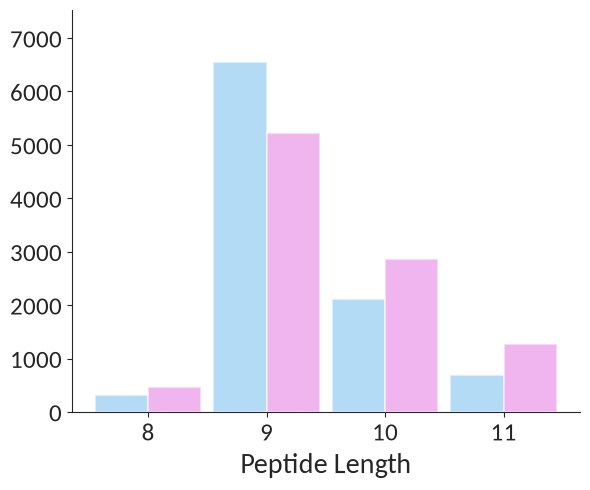

In [13]:
import numpy as np

def plot_kmer_distribution(results: dict, figPath, kmer_range: range = range(8, 12)) -> None:
    """
    Plot side-by-side k-mer length distributions for all datasets in results.

    Parameters
    ----------
    results : dict
        The results dict from load_and_process_cedar, keyed by label.
    kmer_range : range
        Range of peptide lengths to count.
    """
    labels = [f'{i}' for i in kmer_range]
    # Using standard 3-colour palette (CEDAR-pos, CEDAR-neg, Random Self) for group colours
    colors = [PALETTE['CEDAR-pos'], PALETTE['CEDAR-neg'], PALETTE['Random Self']]
    group_colors = {'Immunogenic': PALETTE['CEDAR-pos'], 'Non-Immunogenic': PALETTE['CEDAR-neg'], 'Non-MHC-Binding': PALETTE['Random Self']}

    n_groups = len(labels)
    n_bars = len(results)
    bar_width = 0.45
    x = np.arange(n_groups)
    offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

    fig, ax = plt.subplots(figsize=(6, 5))

    for offset, (label, data) in zip(offsets, results.items()):
        unique_df = data["unique_df"]
        sizes = [
            unique_df[unique_df['Epitope - Name'].str.len() == i].shape[0]
            for i in kmer_range
        ]
        color = group_colors.get(label, colors[0])
        bars = ax.bar(x + offset, sizes, width=bar_width, label=label,
                      color=color, edgecolor='white', linewidth=1.5, alpha=0.5)

        # for bar, size in zip(bars, sizes):
        #     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        #             str(size), ha='center', va='bottom', fontsize=10, fontweight='bold')

    #ax.set_title('Peptide Length Distribution', fontsize=16, fontweight='bold', pad=15)
    # Axis label and tick sizes standardised across thesis figures
    ax.set_xlabel('Peptide Length', fontsize=AXIS_LABEL_FONTSIZE)
    # ax.set_ylabel('Peptide Count', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=TICK_LABEL_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)
    # ax.legend(fontsize=LEGEND_FONTSIZE-2, frameon=True)

    all_sizes = [
        unique_df[unique_df['Epitope - Name'].str.len() == i].shape[0]
        for data in results.values()
        for unique_df in [data["unique_df"]]
        for i in kmer_range
    ]
    ax.set_ylim(0, max(all_sizes) * 1.15)

    plt.tight_layout()
    plt.savefig(figPath, dpi=300)
    plt.show()

cedar_results = dict()
cedar_results["Immunogenic"] = results["Immunogenic"]
cedar_results["Non-Immunogenic"] = results["Non-Immunogenic"]

print(results["Immunogenic"]["unique_df"].shape)
print(results["Non-Immunogenic"]["unique_df"].shape)

plot_kmer_distribution(cedar_results, 'cedar-figures/cedar_pepLenDistribution.png')

HLA Allele distribution

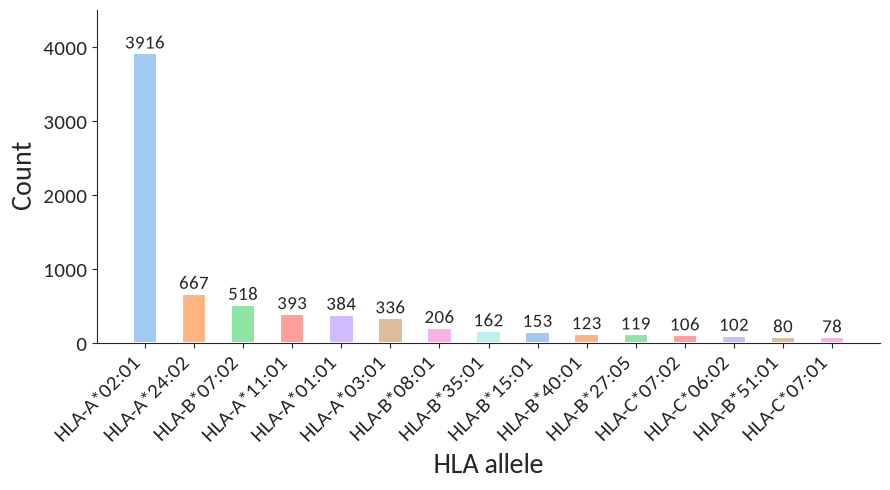

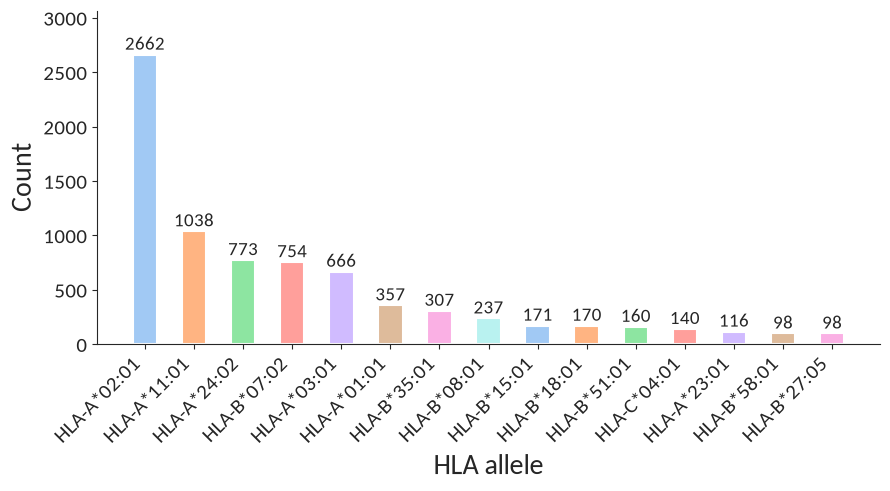

In [26]:
# def plot_value_counts(df, column, title=None, xaxis=None, figsize=(9, 5), top_n=None):
#     """
#     Plot a bar chart of value counts for any dataframe column.
    
#     Parameters:
#         df      : the dataframe
#         column  : column name to visualise
#         title   : optional chart title (defaults to column name)
#         figsize : figure size tuple
#         top_n   : if set, only show the top N most frequent values
#     """
#     counts = df[column].value_counts()
    
#     if top_n:
#         counts = counts.head(top_n)

#     labels = list(counts.index)
#     sizes = list(counts.values)

#     # Generate colors dynamically based on number of bars
#     cmap = plt.colormaps['tab20'].resampled(len(labels))
#     colors = [cmap(i) for i in range(len(labels))]

#     fig, ax = plt.subplots(figsize=figsize)

#     bars = ax.bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

#     for bar, size in zip(bars, sizes):
#         ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
#                 str(size), ha='center', va='bottom', fontsize=10, fontweight='bold')

#     ax.set_title(title if title else f'{column} Distribution', fontsize=16, fontweight='bold', pad=15)
#     ax.set_xlabel(xaxis, fontsize=13)
#     ax.set_ylabel('Count', fontsize=13)
#     ax.spines[['top', 'right']].set_visible(False)
#     ax.set_ylim(0, max(sizes) * 1.15)
#     plt.xticks(rotation=45, ha='right', fontsize=9)

#     plt.tight_layout()
#     plt.show()

# allele_distr_imm_unique = results["Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
# allele_distr_non_imm_unique = results["Non-Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])

# plot_value_counts(allele_distr_imm_unique, 'MHC Restriction - Name', title='HLA Allele Distribution', xaxis='HLA allele', top_n=20)
# plot_value_counts(allele_distr_non_imm_unique, 'MHC Restriction - Name', title='HLA Allele Distribution', xaxis='HLA allele', top_n=20)

def plot_value_counts(df, column, title=None, xaxis=None, figsize=(9, 5), top_n=None,
                       filter_star=False, figPath=None):
    """
    Plot a bar chart of value counts for any dataframe column.
    
    Parameters:
        df          : the dataframe
        column      : column name to visualise
        title       : optional chart title (defaults to column name)
        figsize     : figure size tuple
        top_n       : if set, only show the top N most frequent values
        filter_star : if True, only include values containing '*' (used to
                      exclude badly formatted alleles, e.g. HLA-A*02:01 is
                      kept, malformed entries without a '*' are dropped)
        figPath     : if set, saves the figure to this path at 300 dpi
    """
    if filter_star:
        df = df[df[column].str.contains('*', na=False, regex=False)]

    counts = df[column].value_counts()
    
    if top_n:
        counts = counts.head(top_n)

    labels = list(counts.index)
    sizes = list(counts.values)

    full_pastel = sns.color_palette("pastel", n_colors=30)
    colors = [full_pastel[i] for i in [0, 1, 2, 3, 4, 5, 6, 9, 0, 1, 2, 3, 4, 5, 6, 9, 0, 1, 2, 3, 4, 5, 6, 9, 0, 1, 2, 3, 4, 5, 6, 9,]]
    
    # colors = sns.color_palette("pastel", n_colors=len(labels))

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)

    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(size), ha='center', va='bottom', fontsize=POINT_LABEL_FONTSIZE, fontweight='normal')

    #ax.set_title(title if title else f'{column} Distribution', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(xaxis, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel('Count', fontsize=AXIS_LABEL_FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(sizes) * 1.15)
    plt.xticks(rotation=45, ha='right', fontsize=TICK_LABEL_FONTSIZE - 3)
    plt.yticks(fontsize=TICK_LABEL_FONTSIZE - 3)

    plt.tight_layout()
    if figPath:
        plt.savefig(figPath, dpi=300)
    plt.show()

allele_distr_imm_unique = results["Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
allele_distr_non_imm_unique = results["Non-Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])

plot_value_counts(allele_distr_imm_unique, 'MHC Restriction - Name', title='HLA Allele Distribution', xaxis='HLA allele', top_n=15, filter_star=True, figPath='cedar-figures/imm_HLA_distribution.png')
plot_value_counts(allele_distr_non_imm_unique, 'MHC Restriction - Name', title='HLA Allele Distribution', xaxis='HLA allele', top_n=15, filter_star=True, figPath='cedar-figures/non_imm_HLA_distribution.png')

Pie Chart

findfont: Failed to find font weight 500, now using 400.


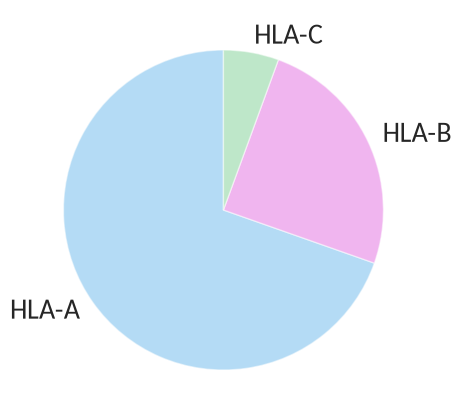

In [14]:
def plot_hla_pie_chart(df, column, title=None, figsize=(6, 6), figPath="."):
    """
    Plot a pie chart showing the proportion of HLA-A, HLA-B, and HLA-C alleles.
    Candidates that do not contain '-A', '-B', or '-C' are ignored.
    """
    # Calculate occurrences using str.contains (na=False safely ignores NaN values)
    a_count = df[column].str.contains('-A', na=False).sum()
    b_count = df[column].str.contains('-B', na=False).sum()
    c_count = df[column].str.contains('-C', na=False).sum()

    # Pair up labels and sizes
    labels_all = ['HLA-A', 'HLA-B', 'HLA-C']
    sizes_all = [a_count, b_count, c_count]

    # Filter out any alleles that might have exactly 0 counts so the chart stays clean
    labels = [l for l, s in zip(labels_all, sizes_all) if s > 0]
    sizes = [s for s in sizes_all if s > 0]

    # Handle edge case where no matches are found
    if not sizes:
        print(f"No HLA-A, -B, or -C alleles found for {title}")
        return

    fig, ax = plt.subplots(figsize=figsize)

    # Generate the pie chart
    ax.pie(
        sizes, 
        labels=labels, 
        # autopct='%1.1f%%', 
        startangle=90, 
        # Using standard 3-colour palette, alpha matched to other seaborn plots
        colors=[PALETTE['CEDAR-pos'], PALETTE['CEDAR-neg'], PALETTE['Random Self']],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'alpha': 0.5},
        textprops={'fontsize': AXIS_LABEL_FONTSIZE, 'fontweight': 500}
    )

    #ax.set_title(title if title else 'HLA Allele Proportions', fontsize=16, fontweight='bold', pad=15)

    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    plt.savefig(figPath, dpi=300)
    plt.show()

allele_distr_imm_unique = results["Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
allele_distr_non_imm_unique = results["Non-Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])

cedar_summary_df = pd.concat(
    [allele_distr_imm_unique, allele_distr_non_imm_unique], 
    ignore_index=True
).drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])

# Call the new pie chart function
# plot_hla_pie_chart(allele_distr_imm_unique, 'MHC Restriction - Name', title='Immunogenic HLA Proportions')
# plot_hla_pie_chart(allele_distr_non_imm_unique, 'MHC Restriction - Name', title='Non-Immunogenic HLA Proportions')

#plot_hla_pie_chart(allele_distr_imm_unique, 'MHC Restriction - Name', title='Immunogenic CEDAR HLA Proportions', figsize=(5, 5), figPath='cedar-figures/imm_HLA_piechart_summary.png')
#plot_hla_pie_chart(allele_distr_non_imm_unique, 'MHC Restriction - Name', title='Non Immunogenic CEDAR HLA Proportions', figsize=(5, 5), figPath='cedar-figures/non_imm_HLA_piechart_summary.png')
plot_hla_pie_chart(cedar_summary_df, 'MHC Restriction - Name', title='CEDAR HLA Proportions', figsize=(5, 5), figPath='cedar-figures/HLA_piechart_summary.png')

Test Sankey Plot

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib.path import Path


# def plot_sankey_allele_distribution(dfs, column, peptide_column='Epitope - Name',
#                                      top_n=10, title=None, figsize=(12, 8),
#                                      save_path=None):
#     """
#     Draw a Sankey diagram comparing allele distributions across multiple dataframes,
#     where each row represents a peptide-allele match (a peptide may appear multiple
#     times if it binds multiple alleles).

#     Left side  : one node per input dataframe, sized by UNIQUE peptide count
#                  (via `peptide_column`), not raw row count.
#     Right side : each dataframe's top_n most common values in `column`, sized and
#                  labeled by the real number of peptide-allele matches (row counts),
#                  with everything else binned into a single 'Other' node.

#     Because a peptide can match multiple alleles, the total peptide-allele matches
#     leaving a dataframe's node can exceed its unique peptide count. To keep the
#     diagram visually balanced, ribbon widths are scaled down proportionally per
#     dataframe so they sum to the true unique peptide count -- but every label still
#     shows the real, unscaled peptide-allele match count.

#     Parameters:
#         dfs            : dict mapping {label: dataframe}, e.g.
#                           {"Immunogenic": df1, "Non-Immunogenic": df2}
#         column         : column name to visualise (e.g. 'MHC Restriction - Name')
#         peptide_column : column identifying a unique peptide (default 'Epitope - Name')
#         top_n          : number of most frequent alleles to show per dataframe
#         title          : optional chart title
#         figsize        : figure size tuple
#         save_path      : optional path to save the figure, e.g. 'sankey.png'
#     """
#     # --- per-dataframe top_n + Other (real, unscaled match counts) -------
#     per_df_counts = {}
#     unique_peptides = {}
#     for label, df in dfs.items():
#         counts = df[column].value_counts()
#         top = counts.head(top_n)
#         other_sum = counts.iloc[top_n:].sum()
#         entry = dict(top)
#         if other_sum > 0:
#             entry['Other'] = other_sum
#         per_df_counts[label] = entry
#         unique_peptides[label] = df[peptide_column].nunique()

#     left_labels = list(dfs.keys())

#     right_labels = []
#     for label in left_labels:
#         for allele in per_df_counts[label]:
#             if allele != 'Other' and allele not in right_labels:
#                 right_labels.append(allele)
#     if any('Other' in per_df_counts[l] for l in left_labels):
#         right_labels.append('Other')

#     # --- scale factor per dataframe: ribbons sum to unique peptide count -
#     scale = {}
#     for label in left_labels:
#         raw_total = sum(per_df_counts[label].values())
#         scale[label] = (unique_peptides[label] / raw_total) if raw_total else 1.0

#     per_df_scaled = {
#         label: {allele: value * scale[label] for allele, value in per_df_counts[label].items()}
#         for label in left_labels
#     }

#     left_totals = unique_peptides  # exact, unscaled unique peptide counts
#     right_totals_scaled = {r: sum(per_df_scaled[l].get(r, 0) for l in left_labels)
#                             for r in right_labels}
#     right_totals_real = {r: sum(per_df_counts[l].get(r, 0) for l in left_labels)
#                           for r in right_labels}

#     total_left = sum(left_totals.values())
#     total_right = sum(right_totals_scaled.values())  # == total_left by construction
#     gap = 0.02  # fraction of total height between stacked nodes

#     def stack_positions(labels, totals, total):
#         y, positions = 0, {}
#         for lab in labels:
#             h = totals[lab]
#             positions[lab] = (y, y + h)
#             y += h + gap * total
#         return positions

#     left_pos = stack_positions(left_labels, left_totals, total_left)
#     right_pos = stack_positions(right_labels, right_totals_scaled, total_right)

#     left_x, right_x, node_w = 0.1, 0.9, 0.03
#     mid = left_x + node_w + (right_x - left_x - node_w) * 0.5

#     fig, ax = plt.subplots(figsize=figsize)

#     cmap_left = plt.colormaps['tab20'].resampled(max(len(left_labels), 1))
#     left_colors = {l: cmap_left(i) for i, l in enumerate(left_labels)}

#     cmap_right = plt.colormaps['tab20b'].resampled(max(len(right_labels), 1))

#     # left nodes -- labeled with real unique peptide counts
#     for lab in left_labels:
#         y0, y1 = left_pos[lab]
#         ax.add_patch(mpatches.Rectangle((left_x, y0), node_w, y1 - y0,
#                                          facecolor=left_colors[lab], edgecolor='white'))
#         ax.text(left_x - 0.01, (y0 + y1) / 2,
#                 f"{lab}\n(n={int(left_totals[lab])} unique peptides)",
#                 ha='right', va='center', fontsize=10, fontweight='bold')

#     # right nodes -- labeled with real peptide-allele match counts
#     for i, lab in enumerate(right_labels):
#         y0, y1 = right_pos[lab]
#         ax.add_patch(mpatches.Rectangle((right_x, y0), node_w, y1 - y0,
#                                          facecolor=cmap_right(i), edgecolor='white'))
#         ax.text(right_x + node_w + 0.01, (y0 + y1) / 2,
#                 f"{lab} (n={int(right_totals_real[lab])})", ha='left', va='center', fontsize=9)

#     # flows -- widths use scaled values, but we keep raw values for reference
#     left_cursor = {l: left_pos[l][0] for l in left_labels}
#     right_cursor = {r: right_pos[r][0] for r in right_labels}

#     for lab in left_labels:
#         for allele, scaled_value in per_df_scaled[lab].items():
#             y0l = left_cursor[lab]; y1l = y0l + scaled_value
#             left_cursor[lab] = y1l

#             y0r = right_cursor[allele]; y1r = y0r + scaled_value
#             right_cursor[allele] = y1r

#             verts = [
#                 (left_x + node_w, y0l), (mid, y0l), (mid, y0r), (right_x, y0r),
#                 (right_x, y1r), (mid, y1r), (mid, y1l), (left_x + node_w, y1l),
#                 (left_x + node_w, y0l),
#             ]
#             codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
#                      Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
#             ax.add_patch(mpatches.PathPatch(Path(verts, codes),
#                                              facecolor=left_colors[lab],
#                                              alpha=0.4, edgecolor='none'))

#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, max(total_left, total_right) * (1 + gap))
#     ax.axis('off')
#     ax.set_title(title if title else f'{column} Distribution Comparison\n(node sizes: unique peptides; labels: real match counts)',
#                  fontsize=15, fontweight='bold', pad=20)

#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.show()
#     plt.close(fig)

#     return fig


# testImm = results["Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
# testNonImm = results["Non-Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', 'MHC Restriction - Name'])
# plot_sankey_allele_distribution(
#     {
#         "Immunogenic": testImm,
#         "Non-Immunogenic": testNonImm,
#     },
#     column='MHC Restriction - Name',
#     peptide_column='Epitope - Name',
#     top_n=5,
#     title='HLA Allele Distribution',
#     save_path='hla_allele_sankey.png',
# )

Peptide Source

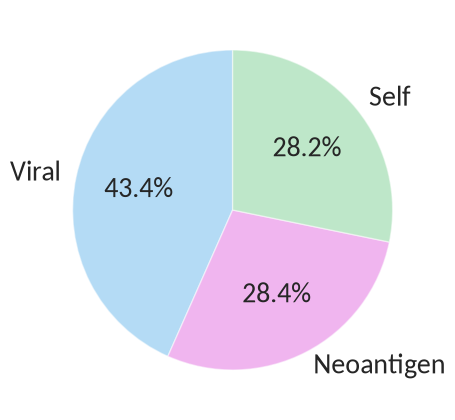

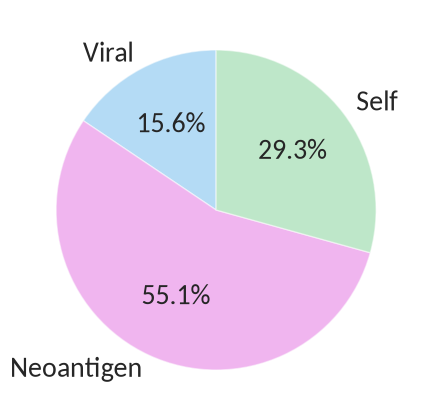

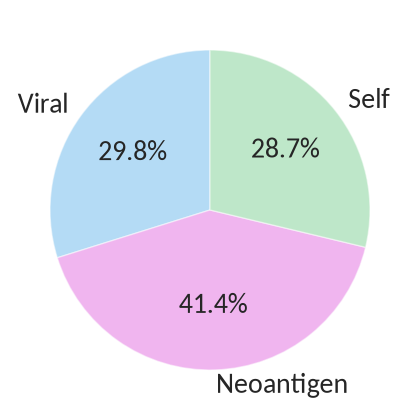

In [ ]:
SOURCE_ORG = "Epitope - Source Organism"

def plot_pepSource_pie_chart(df, column, title=None, figsize=(5, 5), figPath="."):
    """
    Plot a pie chart showing the proportion of HLA-A, HLA-B, and HLA-C alleles.
    Candidates that do not contain '-A', '-B', or '-C' are ignored.
    """
    # Calculate occurrences using str.contains (na=False safely ignores NaN values)
    neoag_count = df[column].isna().sum()
    self_count = df[column].str.contains('Homo', na=False).sum()
    viral_df = df[~df[column].str.contains('Homo', na=False)]
    viral_df = viral_df[~viral_df[column].isna()]
    viral_count=viral_df.shape[0]

    # Pair up labels and sizes
    labels_all = ['Viral', 'Neoantigen', 'Self']
    sizes_all = [viral_count, neoag_count, self_count]

    # Filter out any alleles that might have exactly 0 counts so the chart stays clean
    labels = [l for l, s in zip(labels_all, sizes_all) if s > 0]
    sizes = [s for s in sizes_all if s > 0]

    # Handle edge case where no matches are found
    if not sizes:
        print(f"No HLA-A, -B, or -C alleles found for {title}")
        return

    fig, ax = plt.subplots(figsize=figsize)

    # Generate the pie chart
    ax.pie(
        sizes, 
        labels=labels, 
        # autopct='%1.1f%%', 
        startangle=90, 
        # Using standard 3-colour palette, alpha matched to other seaborn plots
        colors=[PALETTE['CEDAR-pos'], PALETTE['CEDAR-neg'], PALETTE['Random Self']],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'alpha': 0.5},
        textprops={'fontsize': AXIS_LABEL_FONTSIZE, 'fontweight': 500}
    )

    #ax.set_title(title if title else 'HLA Allele Proportions', fontsize=16, fontweight='bold', pad=15)

    # ax.set_xlim(-1.3, 1.3)
    # ax.set_ylim(-1.3, 1.3)
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    plt.savefig(figPath, dpi=300)
    plt.show()

pepSource_distr_imm_unique = results["Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', SOURCE_ORG])
pepSource_distr_non_imm_unique = results["Non-Immunogenic"]["df"].drop_duplicates(subset=['Epitope - Name', SOURCE_ORG])

pepSource_summary_df = pd.concat(
    [pepSource_distr_imm_unique, pepSource_distr_non_imm_unique], 
    ignore_index=True
).drop_duplicates(subset=['Epitope - Name', SOURCE_ORG])

# Call the new pie chart function
# plot_hla_pie_chart(allele_distr_imm_unique, 'MHC Restriction - Name', title='Immunogenic HLA Proportions')
# plot_hla_pie_chart(allele_distr_non_imm_unique, 'MHC Restriction - Name', title='Non-Immunogenic HLA Proportions')

plot_pepSource_pie_chart(pepSource_distr_imm_unique, SOURCE_ORG, title='Immunogenic CEDAR Peptide Source', figsize=(5, 5), figPath='cedar-figures/imm_pepSource_piechart_summary.png')
plot_pepSource_pie_chart(pepSource_distr_non_imm_unique, SOURCE_ORG, title='Non Immunogenic CEDAR Peptide Source', figsize=(5, 5), figPath='cedar-figures/non_imm_pepSource_piechart_summary.png')
plot_pepSource_pie_chart(pepSource_summary_df, SOURCE_ORG, title='CEDAR peptide Sources', figsize=(5, 5), figPath='cedar-figures/pepSource_piechart_summary.png')

Analysis of high viral similarity peptides

{'Viral': 729, 'Neoantigen': 286, 'Self': 89}
{'Viral': 81, 'Neoantigen': 99, 'Self': 29}


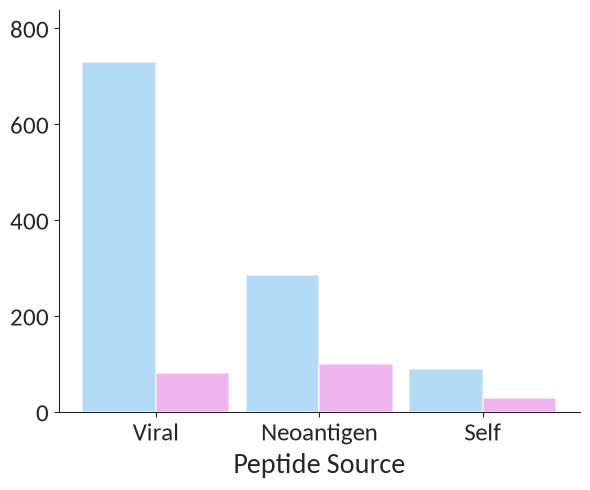

In [14]:
SOURCE_ORG = "Epitope - Source Organism"

def load_peptide_subset(filepath):
    """Read a newline-separated list of peptide sequences into a set."""
    with open(filepath) as f:
        return {line.strip() for line in f if line.strip()}

def get_source_counts(df, peptide_subset, column=SOURCE_ORG):
    """
    Filter df to only peptides in peptide_subset, dedupe on
    (Epitope - Name, source col), and count Viral / Neoantigen / Self.
    """
    subset_df = df[df['Epitope - Name'].isin(peptide_subset)]
    subset_df = subset_df.drop_duplicates(subset=['Epitope - Name', column])

    non_na = subset_df[column].notna()
    is_homo = subset_df[column].str.contains('Homo', na=False)

    return {
        'Viral': int((non_na & ~is_homo).sum()),
        'Neoantigen': int((~non_na).sum()),
        'Self': int((non_na & is_homo).sum()),
    }

def plot_pepSource_distribution(subset_results: dict, figPath):
    """
    Plot side-by-side peptide source distributions (Viral / Neoantigen / Self)
    for each group in subset_results, in the same style as plot_kmer_distribution.

    Parameters
    ----------
    subset_results : dict
        Keyed by label (e.g. 'Immunogenic', 'Non-Immunogenic'), each value a dict
        with key 'counts' -> {'Viral': n, 'Neoantigen': n, 'Self': n}
    figPath : str
        Path to save the figure to.
    """
    categories = ['Viral', 'Neoantigen', 'Self']
    group_colors = {
        'Immunogenic': PALETTE['CEDAR-pos'],
        'Non-Immunogenic': PALETTE['CEDAR-neg'],
        'Non-MHC-Binding': PALETTE['Random Self'],
    }

    n_groups = len(categories)
    n_bars = len(subset_results)
    bar_width = 0.45
    x = np.arange(n_groups)
    offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

    fig, ax = plt.subplots(figsize=(6, 5))

    for offset, (label, data) in zip(offsets, subset_results.items()):
        counts = data["counts"]
        sizes = [counts[cat] for cat in categories]
        color = group_colors.get(label, PALETTE['CEDAR-pos'])
        ax.bar(x + offset, sizes, width=bar_width, label=label,
               color=color, edgecolor='white', linewidth=1.5, alpha=0.5)

    ax.set_xlabel('Peptide Source', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=TICK_LABEL_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)

    all_sizes = [data["counts"][cat] for data in subset_results.values() for cat in categories]
    ax.set_ylim(0, max(all_sizes) * 1.15)

    plt.tight_layout()
    plt.savefig(figPath, dpi=300)
    plt.show()

# --- Load subsets and compute counts ---
imm_subset = load_peptide_subset('peptide-sets/highviralityImmPeps.txt')
non_imm_subset = load_peptide_subset('peptide-sets/highviralityNonImmPeps.txt')

pepSource_subset_results = dict()
pepSource_subset_results["Immunogenic"] = {
    "counts": get_source_counts(results["Immunogenic"]["df"], imm_subset)
}
pepSource_subset_results["Non-Immunogenic"] = {
    "counts": get_source_counts(results["Non-Immunogenic"]["df"], non_imm_subset)
}

print(pepSource_subset_results["Immunogenic"]["counts"])
print(pepSource_subset_results["Non-Immunogenic"]["counts"])

plot_pepSource_distribution(pepSource_subset_results, 'cedar-figures/cedar_pepSourceDistribution_highViralSimilarity.png')

Num Alleles Represented in this set

In [ ]:
import re

def extract_and_normalise_alleles(results: dict) -> dict:
    """
    Extract and normalise MHC allele names for each dataset in results,
    then report alleles unique to each set and those shared across both.

    Parameters
    ----------
    results : dict
        The results dict from load_and_process_cedar, keyed by label.

    Returns
    -------
    allele_sets : dict
        Keyed by label → normalised set of allele strings.
    """
    def normalise_alleles(df: pd.DataFrame) -> np.ndarray:
        alleles = df['MHC Restriction - Name'].unique().copy().astype(str)
        for i, a in enumerate(alleles):
            a = re.sub(r'Cw',              'C',        a)
            a = re.sub(r'([A-Za-z])(\d)$', r'\g<1>0\2', a)
            a = re.sub(r'(-[A-Za-z]+)(?!\*)(\d)', r'\1*\2', a)
            alleles[i] = a
        return alleles

    allele_sets = {}

    for label, data in results.items():
        alleles = normalise_alleles(data["df"])
        allele_sets[label] = set(alleles)
        print(f"\n{'='*60}")
        print(f"  {label}  —  {len(alleles)} alleles")
        print(f"{'='*60}")
        print(sorted(allele_sets[label]))

    # ── Cross-set comparison ─────────────────────────────────────────────────
    labels = list(allele_sets.keys())

    shared = set.intersection(*allele_sets.values())
    print(f"\n{'='*60}")
    print(f"  Alleles shared across ALL sets ({len(shared)})")
    print(f"{'='*60}")
    print(sorted(shared))

    for label, alleles in allele_sets.items():
        others = set.union(*(v for k, v in allele_sets.items() if k != label))
        unique = alleles - others
        print(f"\n{'='*60}")
        print(f"  Alleles unique to {label} ({len(unique)})")
        print(f"{'='*60}")
        print(sorted(unique))

    return allele_sets


allele_sets = extract_and_normalise_alleles(results)


  Immunogenic  —  194 alleles
['H2 class I', 'HLA class I', 'HLA-A*01', 'HLA-A*01:01', 'HLA-A*01:09', 'HLA-A*02', 'HLA-A*02:01', 'HLA-A*02:01 A150P mutant', 'HLA-A*02:01 A69G mutant', 'HLA-A*02:01 E166A mutant', 'HLA-A*02:01 K66A mutant', 'HLA-A*02:01 K66A, E63Q mutant', 'HLA-A*02:01 R65A mutant', 'HLA-A*02:01 T163A mutant', 'HLA-A*02:01 W167A mutant', 'HLA-A*02:02', 'HLA-A*02:03', 'HLA-A*02:04', 'HLA-A*02:05', 'HLA-A*02:06', 'HLA-A*02:07', 'HLA-A*02:09', 'HLA-A*02:10', 'HLA-A*02:11', 'HLA-A*02:16', 'HLA-A*02:17', 'HLA-A*02:20', 'HLA-A*02:24', 'HLA-A*02:402', 'HLA-A*03', 'HLA-A*03:01', 'HLA-A*03:02', 'HLA-A*11', 'HLA-A*11:01', 'HLA-A*11:02', 'HLA-A*23', 'HLA-A*23:01', 'HLA-A*24', 'HLA-A*24:02', 'HLA-A*24:03', 'HLA-A*24:07', 'HLA-A*25', 'HLA-A*25:01', 'HLA-A*26', 'HLA-A*26:01', 'HLA-A*26:02', 'HLA-A*26:03', 'HLA-A*28', 'HLA-A*29', 'HLA-A*29:01', 'HLA-A*29:02', 'HLA-A*30', 'HLA-A*30:01', 'HLA-A*30:02', 'HLA-A*30:04', 'HLA-A*31', 'HLA-A*31:01', 'HLA-A*32', 'HLA-A*32:01', 'HLA-A*32:05', '

### Alleles for training data

#### MHCMotifAtlas Common alleles

In [ ]:
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup

url = "http://mhcmotifatlas.org/class1"

async def get_common_alleles():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        await page.goto(url)
        await page.wait_for_timeout(3000)
        html = await page.content()
        await browser.close()

    soup = BeautifulSoup(html, "html.parser")
    
    # Use find() instead of select() to locate the UL
    allele_ul = soup.find("ul", {"data-alleles-container": True})
    
    # Then filter <li> elements that have the "common" class
    common_alleles = [li for li in allele_ul.find_all("li") if "common" in li.get("class", [])]
    
    # Extract the human-readable label text e.g. "HLA-A*01:01"
    allele_names = [li.find("label").text.strip() for li in common_alleles]
    
    return allele_names

common_alleles = await get_common_alleles()
print(common_alleles)
print(f"Total common alleles: {len(common_alleles)}")

# async def debug_page():
#     async with async_playwright() as p:
#         browser = await p.chromium.launch()
#         page = await browser.new_page()
#         await page.goto(url)
        
#         # Wait longer for JS to load
#         await page.wait_for_timeout(3000)
        
#         html = await page.content()
#         await browser.close()

#     soup = BeautifulSoup(html, "html.parser")
    
#     # Check what's in the allele list
#     allele_ul = soup.find("ul", {"data-alleles-container": True})
#     print("Allele UL found:", allele_ul is not None)
#     print("First 2000 chars of allele UL:", str(allele_ul)[:2000])

# await debug_page()

['HLA-A*01:01', 'HLA-A*02:01', 'HLA-A*02:02', 'HLA-A*02:03', 'HLA-A*02:04', 'HLA-A*02:05', 'HLA-A*02:06', 'HLA-A*02:07', 'HLA-A*02:11', 'HLA-A*02:20', 'HLA-A*02:52', 'HLA-A*03:01', 'HLA-A*03:02', 'HLA-A*11:01', 'HLA-A*11:02', 'HLA-A*23:01', 'HLA-A*24:02', 'HLA-A*24:07', 'HLA-A*25:01', 'HLA-A*26:01', 'HLA-A*26:08', 'HLA-A*29:02', 'HLA-A*30:01', 'HLA-A*30:02', 'HLA-A*31:01', 'HLA-A*32:01', 'HLA-A*33:01', 'HLA-A*33:03', 'HLA-A*34:01', 'HLA-A*34:02', 'HLA-A*36:01', 'HLA-A*66:01', 'HLA-A*68:01', 'HLA-A*68:02', 'HLA-A*69:01', 'HLA-A*74:01', 'HLA-B*07:04', 'HLA-B*08:01', 'HLA-B*13:01', 'HLA-B*13:02', 'HLA-B*14:01', 'HLA-B*14:02', 'HLA-B*15:01', 'HLA-B*15:02', 'HLA-B*15:03', 'HLA-B*15:10', 'HLA-B*15:11', 'HLA-B*15:13', 'HLA-B*15:17', 'HLA-B*15:18', 'HLA-B*18:01', 'HLA-B*18:03', 'HLA-B*18:05', 'HLA-B*27:04', 'HLA-B*27:05', 'HLA-B*27:09', 'HLA-B*35:01', 'HLA-B*35:02', 'HLA-B*35:03', 'HLA-B*35:07', 'HLA-B*35:08', 'HLA-B*37:01', 'HLA-B*38:01', 'HLA-B*38:02', 'HLA-B*39:01', 'HLA-B*39:05', 'HLA-B*39

#### Fix broken alleles using common alleles

In [ ]:
def find_broken_alleles(allele_sets: dict, common_alleles: list) -> dict:
    """
    For each dataset, identify malformed alleles (missing ':'), attempt to
    match them against a reference list of well-formatted common HLA alleles,
    and report those that remain unresolvable.

    Parameters
    ----------
    allele_sets : dict
        Keyed by label → set of normalised allele strings (from extract_and_normalise_alleles).
    common_alleles : list
        Reference list of well-formatted HLA alleles, e.g. ['HLA-A*01:01', ...].

    Returns
    -------
    broken_allele_report : dict
        Keyed by label → {
            'broken':        list of malformed alleles (contain '-', missing ':'),
            'dropped':       list of malformed alleles discarded (no '-' either),
            'replacements':  set of common alleles that could represent broken ones,
            'still_broken':  list of broken alleles with no match in common_alleles,
        }
    """
    report = {}

    for label, alleles in allele_sets.items():
        print(f"\n{'='*60}")
        print(f"  {label}")
        print(f"{'='*60}")

        # ── Step 1: isolate malformed alleles ────────────────────────────────
        broken = [a for a in alleles if ':' not in a]
        print(f"\nBroken alleles (missing ':'): {len(broken)}")
        print(broken)

        # ── Step 2: drop entries that aren't even HLA-like (no '-') ──────────
        dropped  = [a for a in broken if '-' not in a]
        broken   = [a for a in broken if '-'     in a]
        print(f"\nDropped (no '-' either): {len(dropped)}")
        print(dropped)
        print(f"\nFormattable broken alleles remaining: {len(broken)}")
        print(broken)

        # ── Step 3: match broken alleles against the common reference list ───
        replacements = set()
        found        = [False] * len(broken)

        for common in common_alleles:
            for i, b in enumerate(broken):
                if b in common:
                    replacements.add(common)
                    found[i] = True

        still_broken = [b for b, f in zip(broken, found) if not f]

        # ── Step 4: report ───────────────────────────────────────────────────
        print(f"\nCommon alleles searched:                     {len(common_alleles)}")
        print(f"Common alleles matching a broken entry:      {len(replacements)}")
        print(f"Broken alleles with no match in common list: {len(still_broken)}")
        print(f"Still broken: {still_broken}")

        report[label] = {
            'broken':       broken,
            'dropped':      dropped,
            'replacements': replacements,
            'still_broken': still_broken,
        }

    return report


broken_allele_report = find_broken_alleles(allele_sets, common_alleles)


  Immunogenic

Broken alleles (missing ':'): 58
['HLA-C*06', 'HLA-B*53', 'HLA-A*80', 'HLA-B*18', 'HLA-A*01', 'HLA-B*60', 'HLA-B*37', 'HLA-B*07', 'HLA-C*15', 'HLA-C*04', 'HLA-B*52', 'HLA-A*25', 'HLA-A*33', 'HLA-A*32', 'HLA-B*40', 'HLA-C*07', 'HLA-C*03', 'HLA-B*62', 'HLA-C*02', 'HLA-B*50', 'HLA-B*38', 'HLA-B*14', 'HLA-B*15', 'HLA-B*61', 'HLA-B*35', 'HLA-B*42', 'HLA-B*55', 'HLA-C*12', 'HLA-B*51', 'HLA class I', 'HLA-A*03', 'HLA-A*28', 'HLA-B*81', 'HLA-A*02', 'HLA-B*44', 'HLA-A*69', 'HLA-B*39', 'HLA-A*34', 'HLA-B*58', 'HLA-B*12', 'HLA-B*57', 'HLA-B*13', 'HLA-A*26', 'H2 class I', 'HLA-A*29', 'HLA-B*41', 'HLA-A*68', 'HLA-B*27', 'HLA-A*74', 'HLA-A*11', 'HLA-B*08', 'HLA-B*45', 'HLA-A*31', 'HLA-C*08', 'HLA-B*49', 'HLA-A*30', 'HLA-A*24', 'HLA-A*23']

Dropped (no '-' either): 2
['HLA class I', 'H2 class I']

Formattable broken alleles remaining: 56
['HLA-C*06', 'HLA-B*53', 'HLA-A*80', 'HLA-B*18', 'HLA-A*01', 'HLA-B*60', 'HLA-B*37', 'HLA-B*07', 'HLA-C*15', 'HLA-C*04', 'HLA-B*52', 'HLA-A*25', 'HLA

#### Manually add replacements for those not found

* HLA-B\*60: quick google saying it's equivalent to B\*40:01 and B\*40:10. Idk how?
- HLA-B62:  
  - 'B62 is the largest of many split antigens of the broad antigen, B15. B62 best identifies the B\*1501, B\*1504, B\*1507 B\*1525 and B\*1533 allele products.' Wikipedia
- 'HLA-B\*12' 
  - (Important subtypes include B\*44:02, B\*44:03, and B\*44:05.)
- 'HLA-B\*61' 
  - (HLA-B\*40:02 and HLA-B\*40:06)
- 'HLA-A\*80' 
  - (The HLA-A80 allele group is one of the smallest and least common HLA-A families, representing an ancient lineage. The group is dominated by the **HLA-A80:01** allele and includes a few extremely rare variants.)
- 'HLA-A\*28' 
  - (divided into two primary sub-serotypes: HLA-A68 and HLA-A69)



In [ ]:
def find_matching_alleles(allele_sets: dict, broken_allele_report: dict, common_alleles: list) -> dict:
    """
    For each dataset, identify well-formed alleles that are present in the
    common reference list, excluding any broken alleles. Optionally ALLELES_TO_ADD
    known missing entries into each set's replacements before filtering.

    Parameters
    ----------
    allele_sets : dict
        Keyed by label → set of normalised allele strings.
    broken_allele_report : dict
        Keyed by label → report dict from find_broken_alleles.
    common_alleles : list
        Reference list of well-formatted HLA alleles.

    Returns
    -------
    matching_report : dict
        Keyed by label → {
            'matching':  list of valid alleles present in common_alleles,
            'missing':   list of valid alleles absent from common_alleles,
        }
    """

    common_alleles_patched = set(common_alleles) | ALLELES_TO_ADD

    matching_report = {}

    for label, alleles in allele_sets.items():
        broken = set(broken_allele_report[label]['broken'])

        valid    = [a for a in alleles if a not in broken]
        matching = [a for a in valid   if a in common_alleles_patched]
        missing  = [a for a in valid   if a not in common_alleles_patched]

        print(f"\n{'='*60}")
        print(f"  {label}")
        print(f"{'='*60}")
        print(f"Valid (non-broken) alleles:            {len(valid)}")
        print(f"Matching common reference list:        {len(matching)} / {len(valid)}")
        print(f"Valid but absent from reference list:  {len(missing)}")
        print(f"Missing: {sorted(missing)}")

        matching_report[label] = {
            'matching': matching,
            'missing':  missing,
        }

    return matching_report


matching_report = find_matching_alleles(allele_sets, broken_allele_report, common_alleles)


  Immunogenic
Valid (non-broken) alleles:            138
Matching common reference list:        95 / 138
Valid but absent from reference list:  43
Missing: ['H2 class I', 'HLA class I', 'HLA-A*01:09', 'HLA-A*02:01 A150P mutant', 'HLA-A*02:01 A69G mutant', 'HLA-A*02:01 E166A mutant', 'HLA-A*02:01 K66A mutant', 'HLA-A*02:01 K66A, E63Q mutant', 'HLA-A*02:01 R65A mutant', 'HLA-A*02:01 T163A mutant', 'HLA-A*02:01 W167A mutant', 'HLA-A*02:09', 'HLA-A*02:10', 'HLA-A*02:16', 'HLA-A*02:17', 'HLA-A*02:24', 'HLA-A*02:402', 'HLA-A*24:03', 'HLA-A*26:02', 'HLA-A*26:03', 'HLA-A*29:01', 'HLA-A*30:04', 'HLA-A*32:05', 'HLA-B*07:02', 'HLA-B*08:02', 'HLA-B*27:01', 'HLA-B*27:02', 'HLA-B*27:03', 'HLA-B*27:06', 'HLA-B*35:05', 'HLA-B*35:11', 'HLA-B*35:43', 'HLA-B*37:04', 'HLA-B*39:10', 'HLA-B*40:03', 'HLA-B*40:13', 'HLA-B*41:02', 'HLA-B*42:02', 'HLA-B*44:01', 'HLA-B*44:04', 'HLA-B*44:08', 'HLA-B*51:02', 'HLA-B*57:02']

  Non-Immunogenic
Valid (non-broken) alleles:            87
Matching common reference list

Finding the peptide source of CEDAR immunnogenic peptides with high viral similarity

In [41]:
results["Immunogenic"]["unique_df"]['Epitope - Source Organism']

peps = pd.read_csv("peptide-sets/cedar_imm_high_virality.txt", header=None)
display(peps.head)
peps = list(peps[0])
print(peps[0])

viral_high_virality_df = results["Immunogenic"]["viral_df"][results["Immunogenic"]["viral_df"]['Epitope - Name'].isin(peps)]
self_high_virality_df = results["Immunogenic"]["self_df"][results["Immunogenic"]["self_df"]['Epitope - Name'].isin(peps)]
neoag_high_virality_df = results["Immunogenic"]["neoag_df"][results["Immunogenic"]["neoag_df"]['Epitope - Name'].isin(peps)]

print(viral_high_virality_df['Epitope - Source Organism'].shape)
print(self_high_virality_df['Epitope - Source Organism'].shape)
print(neoag_high_virality_df['Epitope - Source Organism'].shape)

<bound method NDFrame.head of                0
0    SSCSSCPLSKV
1     FLPHDFFPSI
2     FLPHDFFPSV
3     FLPADFFPSI
4     FLPADFFPSV
..           ...
900    LLKHSFILM
901    YPRPPGSGL
902    VPVIEDATL
903    AGYDAPRAV
904    ITDFGLAKL

[905 rows x 1 columns]>

SSCSSCPLSKV
(538,)
(90,)
(275,)
